# Figure 3D. Lifestyle information

In [1]:
### Load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [2]:
### load UHGV integration data

# # Download genomad stats file
# !wget https://portal.nersc.gov/cfs/m342/UHGV/mysql/tsv/genomad_viral_stats.tsv

uhgv_proviruses = set(
    pl.read_csv('genomad_viral_stats.tsv', separator='\t', columns=['contig_id', 'provirus'])
    .filter(pl.col('provirus') == "Yes")
    ['contig_id']
)

### get OPD provirus info
# 1. download Excel sheet with metadata: https://static-content.springer.com/esm/art%3A10.1038%2Fs41522-025-00773-z/MediaObjects/41522_2025_773_MOESM2_ESM.xlsx
# 2. Filter Table3-OPD quality to identify 'replace_id' with 'checkv_provirus' == "Yes"
# 3. Save as TSV: opd_checkv_proviruses.tsv
opd_proviruses = set(
    pl.read_csv('opd_checkv_provirus.tsv', separator='\t', columns=['replace_id'])
    ['replace_id']
)

### Get CNGVC integration information
# CNGVC did not perform host trimming, so just used UHVDB provirus info

#### get CGVR provirus info
# 1. CGVR metadata downloaded from: https://static-content.springer.com/esm/art%3A10.1186%2Fs40168-025-02185-9/MediaObjects/40168_2025_2185_MOESM1_ESM.xlsx
# 2. Filter Table S1 to identify 'Viral_bin_id' with 'provirus' == "Yes"
# 3. Save as TSV: cgvr_checkv_proviruses.tsv
cgvr_proviruses = set(
    pl.read_csv('cgvr_checkv_proviruses.tsv', separator='\t', columns=['Viral_bin_id'])
    ['Viral_bin_id']
)

### get IMGVR integration info
# 1. Download IMGVR metadata from: https://genome.jgi.doe.gov/portal/pages/dynamicOrganismDownload.jsf?organism=IMG_VR
imgvr_proviruses = set(
    pl.read_csv('../figure_1/IMGVR_all_Sequence_information.tsv', separator='\t', columns=['UVIG', 'Topology'])
        .filter(pl.col('Topology') == 'Provirus')
        ['UVIG']
)

### get mMGE provirus info
# 1. Download mMGE metadata from: https://mai.fudan.edu.cn/mgedb/client/file/all_mge_inf.zip
mmge_proviruses = set(
    pl.read_csv('../figure_1/all_mge_inf.csv')
        .filter(pl.col('prophage') == True)
        ['MGEs_id']
)

### Identify viruses that were integrated in first run
original_classify_proviruses = set(
    pl.read_csv('../figure_1/viruses.csvtk_concat.tsv', separator='\t', columns=['topology', 'provirus', 'seq_name'])
        .filter((pl.col('topology') == 'Provirus') | (pl.col('provirus') == 'Yes'))
        ['seq_name']
)

integrated_seqs = (
    uhgv_proviruses
    .union(opd_proviruses)
    .union(cgvr_proviruses)
    .union(imgvr_proviruses)
    .union(mmge_proviruses)
    .union(original_classify_proviruses)
)
len(integrated_seqs)

1385581

In [20]:
# map from original id to species
seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping = pl.concat([
    pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t'),
    pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t')
])
seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
uhvdb_source_meta = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')
genomovar_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')

combined = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .join(genomovar_info[['uhvdb_id', 'votu_rep']], left_on='new_id', right_on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep']], left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .join(aaicluster, left_on='votu_rep', right_on='uhvdb_id', how='left')
        .filter(pl.col('seq_name') == pl.col('seqhash_rep'))
        .filter((pl.col('new_id') == pl.col('genomovar_rep')))
        .unique('genomovar_rep')
)

In [4]:
combined.height

508382

In [5]:
### identify UHVDB seqs with integration evidence in original db
uhvdb_integrated_inputs = set(combined.filter(pl.col('seq_name').is_in(integrated_seqs))['genomovar_rep'])
len(uhvdb_integrated_inputs)

83787

In [6]:
## load bacphlip outputs
bacphlip_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/lifestyle/new_genomovars_bacphlip.tsv.gz'):
    df = pl.read_csv(file, separator='\t')
    bacphlip_lst.append(df)

combined_bacphlip = (
    pl.concat(bacphlip_lst)
        .filter(pl.col('').is_in(set(combined['genomovar_rep'])))
)
combined_bacphlip.height

508382

In [7]:
## load classify outputs
classify_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/dereplicate/new_uhvdb_classify.tsv.gz'):
    df = pl.read_csv(file, separator='\t', columns=['uhvdb_id', 'topology', 'provirus'])
    classify_lst.append(df)

combined_classify = (
    pl.concat(classify_lst)
        .filter(pl.col('uhvdb_id').is_in(set(combined['genomovar_rep'])))
        .unique('uhvdb_id')
)
combined_classify.height

508382

In [8]:
## load uhvdb protein outputs
prot_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/function/hq_hc_genomovars_prothash.tsv.gz'):
    df = pl.read_csv(file, separator='\t')
    prot_lst.append(df)

combined_prot = (
    pl.concat(prot_lst)
        .unique('protein_id')
        .with_columns([
            pl.col('protein_id').str.replace(r"_[^_]*$", "").alias('genomovar_id')
        ])
        .filter(pl.col('genomovar_id').is_in(set(combined['genomovar_rep'])))
)
combined_prot.unique('genomovar_id').height

508370

In [9]:
### get pharokka, phold, and empathi results for missing seqs
genomovar_prothashes = set(combined_prot['hash'])
combined_pharokka = pl.read_csv('pharokka_hits.tsv', separator='\t').filter(pl.col('ID').is_in(genomovar_prothashes))
combined_phold = pl.read_csv('phold_hits.tsv', separator='\t').filter(pl.col('cds_id').is_in(genomovar_prothashes))
combined_empathi = pl.read_csv('empathi_hits.tsv', separator='\t').filter(pl.col('').is_in(genomovar_prothashes))

In [10]:
len(genomovar_prothashes)

15120100

In [11]:
# load classify tsv
classify = combined_classify[['uhvdb_id', 'topology', 'provirus']]

# load bacphlip tsv
bacphlip = combined_bacphlip.rename({'': 'uhvdb_id', 'Virulent':'virulent', 'Temperate':'temperate'})

# load protein2hash tsv
protein2hash = (
    combined_prot
        .rename({'hash': 'cds_id'})
        .with_columns([pl.col('protein_id').str.replace(r"_[^_]*$", "").alias('uhvdb_id')])
)

# load pharokka tsv
pharokka = (
   combined_pharokka
        .drop('length')
        .with_columns([pl.col('phrog').cast(pl.String)])
        .rename({'ID':'cds_id'})
        .join(protein2hash, on='cds_id', how='left')
)

# load phold tsv
phold = (
    combined_phold
        .rename({'product':'annot', 'function':'category'})
        [['cds_id', 'phrog', 'annot', 'category']]
        .join(protein2hash, on='cds_id', how='left')
)

# identify integrase/recombinases in pharokka and phold annotations
phrogs = (
    pl.concat([pharokka, phold])
)

phrog_integrases = (
    phrogs
        .filter(pl.col('annot').str.contains(r'integrase|recombinase'))
        .group_by('uhvdb_id')
        .len()
        .rename({'len': 'phrog_integrases'})
)

phrog_integration_excision = (
    phrogs
        .filter(pl.col('category').str.contains('integration and excision'))
        .group_by('uhvdb_id')
        .len()
        .rename({'len': 'phrog_integration_excision'})
)

# load empathi csv
empathi = (
    combined_empathi
        .filter(pl.col('Annotation').str.contains('integration'))
        .rename({'': 'cds_id'})
        .join(protein2hash, on='cds_id', how='left')
        .group_by('uhvdb_id')
        .len()
        .rename({'len': 'empathi_integration'})
)

# combine all results
combined_lifestyles = (
    classify
        .join(bacphlip, on='uhvdb_id', how='inner')
        .join(phrog_integrases, on='uhvdb_id', how='left')
        .join(phrog_integration_excision, on='uhvdb_id', how='left')
        .join(empathi, on='uhvdb_id', how='left')
)

In [12]:
combined_lifestyles.write_csv('uhvdb_v4_lifestyle.tsv', separator='\t')

In [13]:
# proportion of complete genomes that are 
import polars as pl
combined_lifestyles = pl.read_csv('uhvdb_v4_lifestyle.tsv', separator='\t', schema_overrides={'phrog_integrases':pl.Int64})
plot_df = (
    combined_lifestyles
        .with_columns([
            pl.when(
                (pl.col('topology') == 'Provirus') |
                (pl.col('provirus') == 'Yes') |
                (pl.col('uhvdb_id').is_in(uhvdb_integrated_inputs))
            )
                .then(pl.lit('Integrated'))
                .otherwise(pl.lit('No evidence of integration'))
                .alias('integration_status'),
            pl.when(pl.col('temperate') > 0.5)
                .then(pl.lit('BACPHLIP temperate'))
                .otherwise(pl.lit('BACPHLIP virulent'))
                .alias('BACPHLIP'),
            pl.when(pl.col('phrog_integrases') > 0)
                .then(pl.lit('Integrase present'))
                .otherwise(pl.lit('No integrase'))
                .alias('phrog_integrases'),
            pl.when(pl.col('phrog_integration_excision') > 0)
                .then(pl.lit('Integration/Excision present'))
                .otherwise(pl.lit('No integration/excision'))
                .alias('phrog_integration_excision'),
            pl.when(pl.col('empathi_integration') > 0)
                .then(pl.lit('Empathi integration evidence'))
                .otherwise(pl.lit('No Empathi integration evidence'))
                .alias('empathi_integration')
        ])
)

In [21]:
plot_df_final = (
    plot_df
        .join(combined[['genomovar_rep', 'body_site']].unique('genomovar_rep'), left_on='uhvdb_id', right_on='genomovar_rep', how='full', coalesce=True)
)

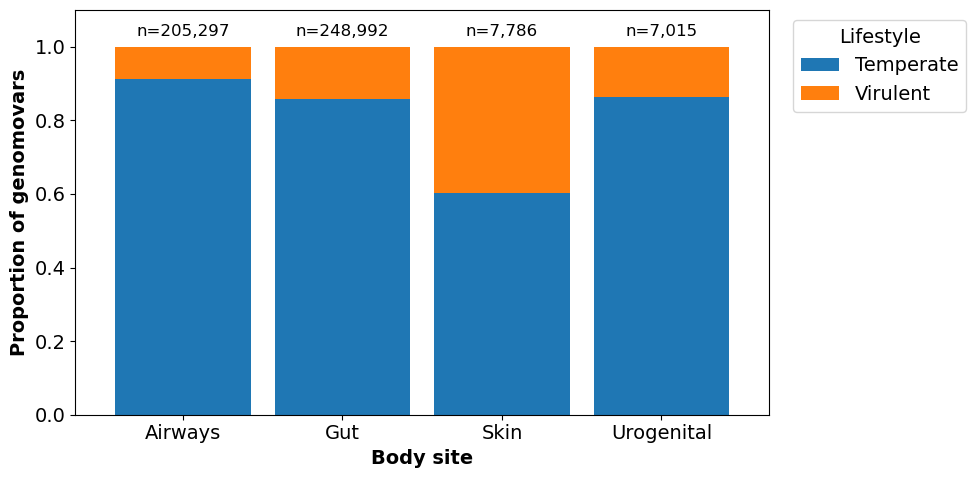

In [30]:
# Assign one temperate-evidence label per genome, then plot body-site proportions
# Priority order keeps categories mutually exclusive for stacking
plt.rcParams.update({'font.size': 14})
method_order = [
    'Temperate',
    'Virulent'
]

classified = (
    plot_df_final
        .filter(pl.col('body_site').is_not_null())
        .with_columns([
            pl.when(pl.col('integration_status') == 'Integrated')
                .then(pl.lit('Temperate'))
                .when(pl.col('BACPHLIP') == 'BACPHLIP temperate')
                .then(pl.lit('Temperate'))
                .when(pl.col('phrog_integrases') == 'Integrase present')
                .then(pl.lit('Temperate'))
                .when(pl.col('phrog_integration_excision') == 'Integration/Excision present')
                .then(pl.lit('Temperate'))
                .when(pl.col('empathi_integration') == 'Empathi integration evidence')
                .then(pl.lit('Temperate'))
                .otherwise(pl.lit('Virulent'))
                .alias('lifestyle')
        ])
)

site_counts = (
    classified
        .group_by(['body_site', 'lifestyle'])
        .len()
        .rename({'len': 'count'})
)

site_totals = (
    classified
        .group_by('body_site')
        .len()
        .rename({'len': 'total'})
)

body_sites = classified.select('body_site').unique()
all_methods = pl.DataFrame({'lifestyle': method_order})

body_method_props = (
    body_sites
        .join(all_methods, how='cross')
        .join(site_counts, on=['body_site', 'lifestyle'], how='left')
        .join(site_totals, on='body_site', how='left')
        .with_columns([
            pl.col('count').fill_null(0),
            (pl.col('count').fill_null(0) / pl.col('total')).alias('proportion')
        ])
        .filter(pl.col('body_site') != 'Other')
        .select(['body_site', 'lifestyle', 'count', 'proportion'])
)

# Stacked bar chart: body site on x-axis
plot_pdf = body_method_props.to_pandas()
pivot_df = (
    plot_pdf
    .pivot(index='body_site', columns='lifestyle', values='proportion')
    .fillna(0)
)[method_order]

# Use default matplotlib colors for everything except no temperate evidence
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# colors = [default_colors[i % len(default_colors)] for i in range(len(method_order) - 1)] + ['#D9D9D9']

# Bar labels with total counts
site_total_pdf = site_totals.filter(pl.col('body_site') != 'Other').to_pandas().set_index('body_site')
site_total_pdf = site_total_pdf.reindex(pivot_df.index)

ax = pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5),
    # color=colors,
    width=0.85
)

ax.set_xlabel('Body site', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Proportion of genomovars', fontdict={'fontweight': 'bold'})
ax.legend(title='Lifestyle', bbox_to_anchor=(1.02, 1), loc='upper left')

# Display totals above each bar
for i, body_site in enumerate(pivot_df.index):
    total = int(site_total_pdf.loc[body_site, 'total'])
    ax.text(i, 1.02, f'n={total:,}', ha='center', va='bottom', fontsize=12)

ax.set_ylim(0, 1.10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
pivot_df

lifestyle,Temperate,Virulent
body_site,,
Airways,0.912663,0.087337
Gut,0.858441,0.141559
Skin,0.601593,0.398407
Urogenital,0.863008,0.136992


In [28]:
print("Total number of genomovars:", classified.height)
print("Total number of temperate genomovars:", classified.filter(pl.col('lifestyle') == 'Temperate').height)
print("Proportion of temperate genomovars:", classified.filter(pl.col('lifestyle') == 'Temperate').height / classified.height)

Total number of genomovars: 508178
Total number of temperate genomovars: 444077
Proportion of temperate genomovars: 0.8738611274002417


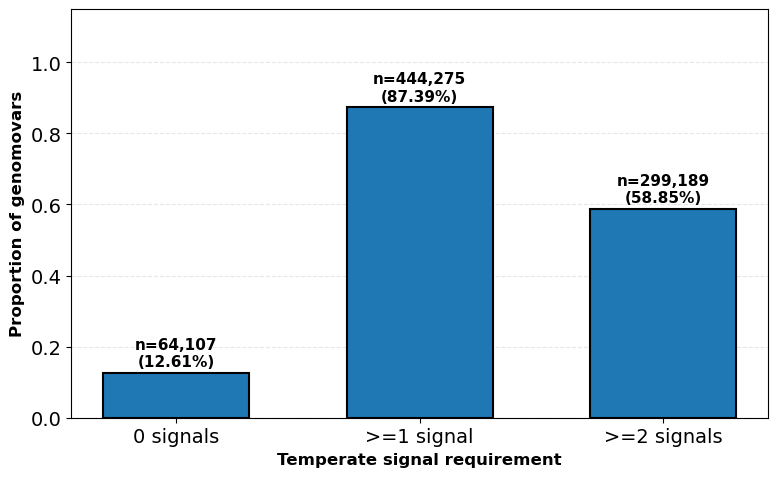

In [16]:
### Plot proportion of sequences with 0, >=1, and >=2 temperate signals

# Count temperate signals for each sequence
signal_counts = (
    combined_lifestyles
        .with_columns([
            (
                (pl.col('uhvdb_id').is_in(uhvdb_integrated_inputs)).fill_null(False).cast(pl.Int32)
                + (pl.col('temperate').cast(pl.Float64, strict=False) > 0.5).fill_null(False).cast(pl.Int32)
                + (
                    (pl.col('phrog_integrases').cast(pl.Float64, strict=False) >= 1)
                    | (pl.col('phrog_integration_excision').cast(pl.Float64, strict=False) >= 1)
                    | (pl.col('empathi_integration').cast(pl.Float64, strict=False) >= 1)
                ).fill_null(False).cast(pl.Int32)
            ).alias('temperate_signal_count')
        ])
)

# Calculate proportions at each threshold
total_count = signal_counts.height
threshold_proportions = []

for threshold in [0, 1, 2]:
    if threshold == 0:
        n_at_threshold = signal_counts.filter(pl.col('temperate_signal_count') == 0).height
        label = '0 signals'
    else:
        n_at_threshold = signal_counts.filter(pl.col('temperate_signal_count') >= threshold).height
        label = f'>={threshold} signal{"s" if threshold != 1 else ""}'
    
    proportion = n_at_threshold / total_count
    threshold_proportions.append({'threshold': label, 'count': n_at_threshold, 'proportion': proportion})

threshold_df = pl.DataFrame(threshold_proportions)

# Create bar plot
fig, ax = plt.subplots(figsize=(8, 5))
threshold_df_pd = threshold_df.to_pandas()

bars = ax.bar(threshold_df_pd['threshold'], threshold_df_pd['proportion'], width=0.6, edgecolor='black', linewidth=1.5)

# Add count labels above bars
for i, (bar, count) in enumerate(zip(bars, threshold_df_pd['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'n={int(count):,}\n({height:.2%})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Proportion of genomovars', fontdict={'fontweight': 'bold'}, fontsize=12)
ax.set_xlabel('Temperate signal requirement', fontdict={'fontweight': 'bold'}, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()